 [1. Problem definition](#1.-Problem-definition)\
 [2. Data collection](#2.-Data-collection)\
 [3. Exploratory data analysis and preprocessing](#3.-Exploratory-data-analysis-and-preprocessing)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.1 Data structure](##3.1-Data-structure)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.2 Duplicate values](##3.2-Duplicate-values)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.3 Missing values](##3.3-Missing-values)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.4 Outliers](##3.4-Outliers)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.5 Univariate and multivariate analysis of the data](##3.5-Univariate-and-multivariate-analysis-of-the-data)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.6 Sampling (Data splitting)](##3.6-Data-splitting)\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.6.1 Split data into train and test](##3.6.1-Split-data-into-train-and-train)\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.6.2 Balancing data](##3.6.2-Balancing-data)\
&nbsp;&nbsp;&nbsp;&nbsp;[3.7 Feature transformations](##3.7-Feature-transformations)\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.7.1 Encoding Categorical variables](###3.7.1-Encoding-categorical-variables)\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.7.2 Scaling numerical variables](###3.7.2-Scaling-numerical-variables)\
 [4. Feature selection**](#4.-Feature-selection**)\
 [5. Model selection](#5.-Model-selection)\
&nbsp;&nbsp;&nbsp;&nbsp;[5.1 Training (Classification, Regression, Clustering)](##5.1-Training-(Classification-Regression-Clustering))\
&nbsp;&nbsp;&nbsp;&nbsp;[5.2 Evaluation](##5.2-Evaluation)\
 [7. Model Deployment](#7.-Model-Deployment)\
 [8. Model monitoring and maintenance](#8.-Model-monitoring-and-maintenance)

# 1. Problem definition

# 2. Data collection

# 3. Exploratory data analysis and preprocessing

## 3.1 Data structure

## 3.2 Duplicate values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
# from sklearn.ensemble import ...
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [17]:
df.duplicated().sum()

0

In [18]:
df.drop_duplicates()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [24]:
round((df.isnull().sum()/df.shape[0])*100,2)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [30]:
df.drop(columns = "Pregnancies", inplace = True)

In [32]:
df.dropna(subset = "BMI", axis=0, inplace=True)

In [40]:
cat = list(df.select_dtypes(include = "object").columns)
num = list(df.select_dtypes(exclude = "object").columns)


['Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [33]:
df.nunique()

Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

<Axes: ylabel='Glucose'>

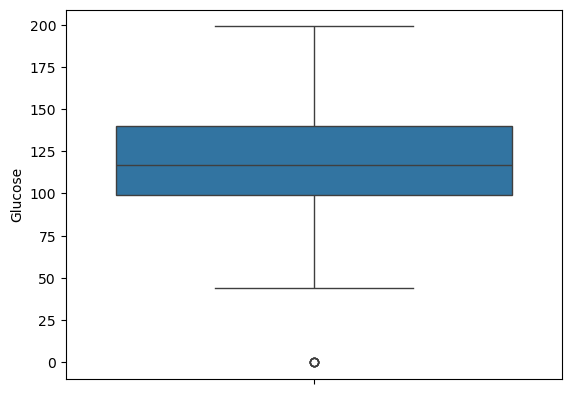

In [28]:
sns.boxplot(df["Glucose"])

In [41]:
from sklearn.preprocessing import MinMaxScaler

# initialising the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Numerical columns
# num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = df
# learning the statistical parameters for each of the data and transforming
x1[num] = scaler.fit_transform(x1[num])
x1.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,0.483333,1.0
1,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,0.166667,0.0
2,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,0.183333,1.0
3,0.447236,0.540984,0.232323,0.111111,0.418778,0.038002,0.000000,0.0
4,0.688442,0.327869,0.353535,0.198582,0.642325,0.943638,0.200000,1.0
